In [20]:
# --- Simple Deep Learning Model using sklearn ---

# imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


In [21]:
# Set random seed for reproduciblity
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [22]:
#-------------#
# Data Loading
#-------------#

# uploading Kaggle API key
from google.colab import files
files.upload()

# Configure Kaggle API
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading and unzip Kaggle's Data

!kaggle competitions download -c house-prices-advanced-regression-techniques
!unzip house-prices-advanced-regression-techniques.zip

# Loading training Data
data = pd.read_csv('train.csv')
print("Training Data is loaded successfully. Shape:", data.shape)
data.head()

Saving kaggle.json to kaggle.json
house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  house-prices-advanced-regression-techniques.zip
replace data_description.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data_description.txt    
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: sample_submission.csv   
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: test.csv                
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train.csv               
Training Data is loaded successfully. Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [23]:
#-------------------#
# Data Preprocessing
#-------------------#

# 1. Drop 'Id' column
data = data.drop(columns='Id', errors='ignore')

# 2. Seperate input features (X) and target (y)
X = data.drop(columns = 'SalePrice', errors= 'ignore' )
y = data['SalePrice']

# 3. Log-transform to the target to prevent skeweness
y_log = np.log1p(y)

# 4. Train/Validation Split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y_log, test_size=0.2, random_state=SEED)

# 5. Handle Categorical Features
X_train_encoded = pd.get_dummies(X_train_raw)
X_val_encoded = pd.get_dummies(X_val_raw)
X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)

# 6. Impute Missing Values
imputer = SimpleImputer(strategy='median')

# Fit on training and validation data
X_train_imputed = imputer.fit_transform(X_train_encoded)
X_val_imputed = imputer.transform(X_val_encoded)

# 7. Scale the Data (Mean = 0 , Std = 1)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)


print(f"Data preprocessing complete. Training shape: {X_train_scaled.shape}")
print(f"Mean of scaled data: {X_train_scaled.mean():.2f}")
print(f"Std of scaled data: {X_train_scaled.std():.2f}")

Data preprocessing complete. Training shape: (1168, 285)
Mean of scaled data: 0.00
Std of scaled data: 1.00


In [24]:
# 1. Define a list of models to test
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(max_depth=15, random_state=SEED)),
    ('Random Forest', RandomForestRegressor(n_estimators=200, random_state=SEED)),
    ('SVM', SVR(kernel='rbf')),
    ('XGBoost' , XGBRegressor(
    n_estimators=1000,   # High number of trees, but it stops when it stops improving
    learning_rate=0.05,  # Slows down learning to be more precise
    max_depth=6,         # Shorter trees than RF to prevent memorizing
    subsample=0.8,       # Uses 80% of data for each tree to stay diverse
    colsample_bytree=0.8,# Uses 80% of features (columns)
    random_state=SEED,
    n_jobs=-1
))
]
# 2. Looping through the model and evaluate each one
print("Model Performance (RMSE):")

# Cross-Validation divides the rows of training data into 5 equal chunks. train by 4 chunks and tests it by 1 chunk and repeats it 5 times
for name, model in models:
  scores= cross_val_score(model, X_train_scaled, y_train, scoring='neg_mean_squared_error', cv=5)

  # Coonvert back to positive RMSE
  rmse_scores = np.sqrt(-scores)

  print(f"{name}: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

Model Performance (RMSE):
Linear Regression: 0.1541 (+/- 0.0147)
Decision Tree: 0.2075 (+/- 0.0165)
Random Forest: 0.1446 (+/- 0.0205)
SVM: 0.1943 (+/- 0.0228)
XGBoost: 0.1329 (+/- 0.0173)


Random Forest Validation RMSE (Log): 0.1527
Training RMSE (Log): 0.0960
(Random Forest) On average, the model is off by: $32,801.96


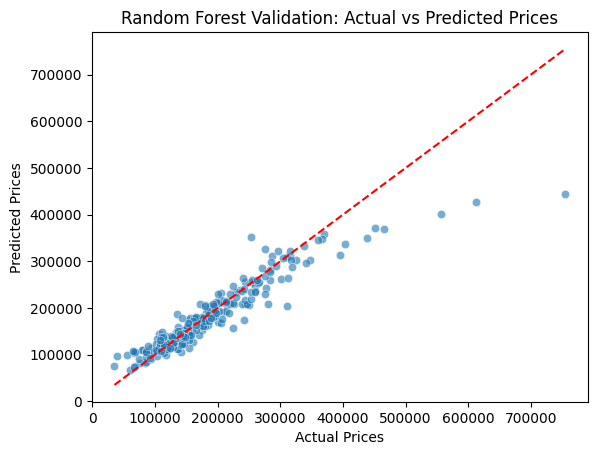

In [25]:
#------------------------------#
#  Random Forest Model Training
#------------------------------#


# 1. Initialize the model

# We increase n_estimators to 500 to make it more stable to have lower Std Dev
rf_model = RandomForestRegressor(n_estimators=500,
                                 max_depth=20,
                              min_samples_leaf=5, # Each "rule" must apply to at least 5 houses
                              max_features=0.5,    # Only look at 50% of columns for each tree
                                 random_state= SEED,
                                 n_jobs=-1)

# 2. Train the model
rf_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the validation set
y_val_pred = rf_model.predict(X_val_scaled)
# 4. Calculate RMSE in Log units
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
# Validation RMSE is the Practice Score.
print(f"Random Forest Validation RMSE (Log): {val_rmse:.4f}")

# Making the same steps for the Training Set to check Overfitting
y_train_pred = rf_model.predict(X_train_scaled)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Training RMSE (Log): {rf_train_rmse:.4f}")

# Convert log-prices back to actual Dollars
y_val_actual = np.expm1(y_val)
y_pred_actual = np.expm1(y_val_pred)


# Calculate the average error in Dollars
actual_error = np.sqrt(mean_squared_error(y_val_actual, y_pred_actual))
print(f"(Random Forest) On average, the model is off by: ${actual_error:,.2f}")


# flattens multi-dimensional arrays into 1D arrays.
y_true_val = np.ravel(y_val_actual)  # or .flatten()
y_pred_val = np.ravel(y_pred_actual)
# scatter plot of predictions vs true values
sns.scatterplot(x=y_true_val, y=y_pred_val, alpha=0.6)
# Drawing red dashed line
plt.plot([y_true_val.min(), y_true_val.max()],
         [y_true_val.min(),y_true_val.max()], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Random Forest Validation: Actual vs Predicted Prices')
plt.show()



XGBoost Validation RMSE: 0.1318
Training RMSE (Log): 0.0837
(XGBoost) On average, the model is off by: $27,630.50


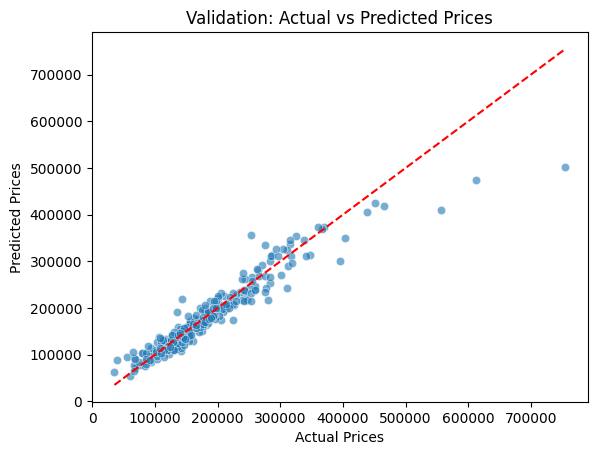

In [26]:
#------------------------------#
#  XGBoost Model Training
#------------------------------#


# 1. Initialize XGBoost
xgb_model = XGBRegressor(
    n_estimators=1000,   # High number of trees, but it stops when it stops improving
    learning_rate=0.05,  # Slows down learning to be more precise
    max_depth=2,         # Shorter trees than RF to prevent memorizing
    subsample=0.8,       # Uses 80% of data for each tree to stay diverse
    colsample_bytree=0.8,# Uses 80% of features (columns)
    random_state=SEED,
    reg_lambda=40,    # Increasing L2 penalty to 10 to reduce overfitting
    n_jobs=-1
)

# 2. Train the model
xgb_model.fit(X_train_scaled, y_train)

# 3. Predict and Calculate RMSE
y_pred_xgb = xgb_model.predict(X_val_scaled)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))

print(f"XGBoost Validation RMSE: {rmse_xgb:.4f}")


# Making the same steps for the Training Set to check Overfitting
y_train_pred = xgb_model.predict(X_train_scaled)
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Training RMSE (Log): {xgb_train_rmse:.4f}")

# Convert log-prices back to actual Dollars
y_val_actual = np.expm1(y_val)
y_pred_actual = np.expm1(y_pred_xgb)


# Calculate the average error in Dollars
actual_error = np.sqrt(mean_squared_error(y_val_actual, y_pred_actual))
print(f"(XGBoost) On average, the model is off by: ${actual_error:,.2f}")


# flattens multi-dimensional arrays into 1D arrays.
y_true_val = np.ravel(y_val_actual)  # or .flatten()
y_pred_val = np.ravel(y_pred_actual)
# scatter plot of predictions vs true values
sns.scatterplot(x=y_true_val, y=y_pred_val, alpha=0.6)
# Drawing red dashed line
plt.plot([y_true_val.min(), y_true_val.max()],
         [y_true_val.min(),y_true_val.max()], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Validation: Actual vs Predicted Prices')
plt.show()


In [27]:
#------------------------------#
#  Ensembling the Two Models
#------------------------------#

ensemble_voting = VotingRegressor(estimators=[
    ('rf', rf_model),
    ('xgb',xgb_model)
],weights=[1,2])

ensemble_voting.fit(X_train_scaled, y_train)
voting_pred = ensemble_voting.predict(X_val_scaled)
ensemble_train_pred= ensemble_voting.predict(X_train_scaled)

ensemble_train_rmse = np.sqrt(mean_squared_error(y_train, ensemble_train_pred))

rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred))
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
rmse_ensemble = np.sqrt(mean_squared_error(y_val, voting_pred))

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Training RMSE (Log): {rf_train_rmse:.4f}")
print(f"XGBoost RMSE:       {rmse_xgb:.4f}")
print(f"Training RMSE (Log): {xgb_train_rmse:.4f}")
print(f"Ensemble RMSE:      {rmse_ensemble:.4f}")
print(f"Training RMSE (Log): {ensemble_train_rmse:.4f}")


Random Forest RMSE: 0.1527
Training RMSE (Log): 0.0960
XGBoost RMSE:       0.1318
Training RMSE (Log): 0.0837
Ensemble RMSE:      0.1350
Training RMSE (Log): 0.0838


The Most reliable Model based on the two curves is the Ensembled Model 


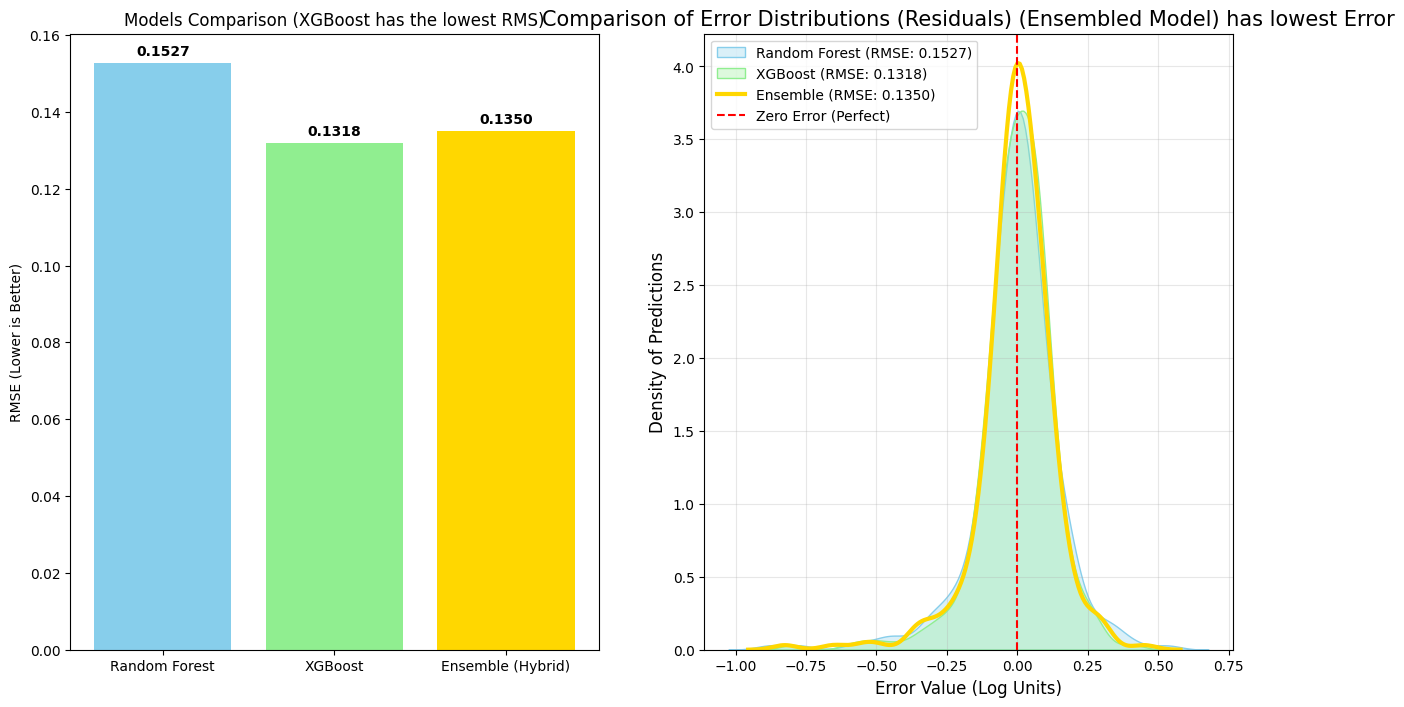

In [31]:

#------------------------------#
#  Choosing the Best Model
#------------------------------#

### Bar Chart ###
models = ['Random Forest', 'XGBoost', 'Ensemble (Hybrid)']
results = [rmse_rf, rmse_xgb, rmse_ensemble]

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(15,8))
ax1.bar(models, results, color=['skyblue', 'lightgreen', 'gold'])

ax1.set_title('Models Comparison (XGBoost has the lowest RMS)')
ax1.set_ylabel('RMSE (Lower is Better)')
for i, v in enumerate(results):
    ax1.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')

### Residual Curve ###
# 1. Calculate the Error distribution for each model (Residual Curve)
rf_residuals = y_val - y_val_pred
xgb_residuals = y_val - y_pred_xgb
ensemble_residuals = y_val - voting_pred

# Plot the "curves"
sns.kdeplot(rf_residuals, label=f'Random Forest (RMSE: {rmse_rf:.4f})', color='skyblue', fill=True, alpha=0.3)
sns.kdeplot(xgb_residuals, label=f'XGBoost (RMSE: {rmse_xgb:.4f})', color='lightgreen', fill=True, alpha=0.3)
sns.kdeplot(ensemble_residuals, label=f'Ensemble (RMSE: {rmse_ensemble:.4f})', color='gold', linewidth=3)

# 3. Add a vertical line at 0 (The "Perfect Prediction" line)
ax2.axvline(x=0, color='red', linestyle='--', label='Zero Error (Perfect)')

# 4. Styling
ax2.set_title('Comparison of Error Distributions (Residuals) (Ensembled Model) has lowest Error', fontsize=15)
ax2.set_xlabel('Error Value (Log Units)', fontsize=12)
ax2.set_ylabel('Density of Predictions', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

print("The Most reliable Model based on the two curves is the Ensembled Model ")
plt.show()


In [29]:
#---------------------------------------------------#
#  Generating the Final Kaggle Submission
#---------------------------------------------------#

# 1. Load the actual Test Data
test_data = pd.read_csv('test.csv')

# 2. Preprocessing (Must match training exactly)
# Drop Id
X_test = test_data.drop(columns='Id', errors='ignore')

# One-Hot Encoding
X_test_encoded = pd.get_dummies(X_test)

# Align with Training columns (This adds missing categories as 0s)
_, X_test_aligned = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 3. Impute and Scale
X_test_imputed = imputer.transform(X_test_aligned)
X_test_scaled = scaler.transform(X_test_imputed)

# 4. Predict using your Champion Ensemble
# The predictions will be in LOG units
test_preds_log = ensemble_voting.predict(X_test_scaled)

# 5. Convert back to Actual Dollars (The Inverse of Log)
test_preds_final = np.expm1(test_preds_log)

# 6. Create the Submission DataFrame
submission = pd.DataFrame({
    'Id': test_data['Id'],
    'SalePrice': test_preds_final
})

# 7. Save to CSV
submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully!")
submission.head()

from google.colab import files
files.download("submission.csv")
print(submission.shape)

Submission file 'submission.csv' created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(1459, 2)


In [35]:
import joblib

# Save ensemble model as a pickle
joblib.dump(ensemble_voting, 'ensemble_model.pkl')
files.download('ensemble_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>